# Human Colon Purple/White Segmentation Audit

This notebook mirrors the human-colon ROI from `ARI_fig.ipynb` and compares only the three visual methods shown there:

- StarDist nuclei
- Cellpose nuclei
- Cellpose cytoplasm

The goal is to ask two image-based questions inside the ROI:

1. Are segmented objects enriched for hematoxylin/purple signal, as expected for nuclei?
2. How much purple signal is missed, and how much bright/white goblet-like area is included or missed?


In [118]:
from pathlib import Path
import os

from tifffile import imread
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib_scalebar.scalebar import ScaleBar
from PIL import Image, ImageDraw
import seaborn as sns

from shapely.geometry import box
from skimage import color, filters, morphology

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
sns.set_theme(style='whitegrid')

ROOT = Path('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval')
FIG_DIR = ROOT / 'analysis' / 'figures' / 'purple_white_fig'
FIG_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_PATH = ROOT / 'data' / 'human_colon' / 'Visium_HD_Human_Colon_Cancer_tissue_image.btf'
RUN_DIR = ROOT / 'analysis' / 'human_colon' / 'human_colon_run'

METHOD_FILES = {
    'StarDist Nuclei': RUN_DIR / 'stardist_nuclei.gpkg',
    'Cellpose Nuclei': RUN_DIR / 'cellpose_nuclei.gpkg',
    'Cellpose Cytoplasm': RUN_DIR / 'cellpose_cyto.gpkg',
}

# Same human-colon ROI used in ARI_fig.ipynb. Coordinates are full-resolution image pixels.
region_x = [55000, 55500]
region_y = [11500, 12000]
microns_per_pixel = 0.2738242950835738


## Color Filter Rationale

### Purple / nuclear-looking pixels

Purple/nuclear-looking pixels are identified with a standard, publication-friendly H&E color-deconvolution workflow. RGB pixels are converted to HED stain space with `skimage.color.rgb2hed` (Ruifrok-Johnston color deconvolution). The hematoxylin channel is then thresholded automatically with Otsu's method within non-white tissue pixels. This is intentionally simple and reproducible: **purple = tissue pixel, not white/goblet-like, and above the Otsu hematoxylin threshold**. This avoids hand-picked RGB/hue cutoffs while measuring the stain channel most directly associated with nuclei.

### White / goblet-like pixels

Goblet mucin/empty regions appear bright and weakly saturated in H&E. The white mask therefore uses slightly inclusive HSV thresholds (`value >= 0.5`, `saturation <= 0.35`) inside a morphologically filled local tissue context. The tissue-context step prevents blank slide/background from being counted as goblet-like white while keeping bright holes embedded in tissue.

These masks are meant as visual/quantitative QC filters, not definitive cell-type labels. The purple cutoff is automatic; the white thresholds are exposed below because bright goblet/lumen-like regions are less stain-specific than hematoxylin-positive nuclei.


In [119]:
WHITE_MAX_SATURATION = 0.35
WHITE_MIN_VALUE = 0.5

TISSUE_MIN_SATURATION = 0.05
TISSUE_MAX_VALUE_FOR_NONBACKGROUND = 0.92
TISSUE_HOLE_AREA_PX = 2500
TISSUE_MIN_OBJECT_PX = 500

def as_rgb_float(img):
    """Return an RGB image in [0, 1] for display and color calculations."""
    if img.ndim == 2:
        rgb = np.repeat(img[..., None], 3, axis=2)
    else:
        rgb = img[..., :3]

    rgb = rgb.astype(np.float32)
    if np.issubdtype(img.dtype, np.integer):
        p999 = np.nanpercentile(rgb, 99.9)
        denom = 255.0 if p999 <= 255 else float(np.iinfo(img.dtype).max)
    else:
        denom = 1.0 if np.nanmax(rgb) <= 1 else np.nanmax(rgb)
    return np.clip(rgb / denom, 0, 1)

def safe_otsu(values, fallback_quantile=0.75):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        raise ValueError('No pixels available for Otsu thresholding; check the ROI and tissue mask.')
    if values.size < 20 or np.nanmin(values) == np.nanmax(values):
        return float(np.nanquantile(values, fallback_quantile))
    return float(filters.threshold_otsu(values))


In [120]:
full_img = imread(IMAGE_PATH)
crop = full_img[region_y[0]:region_y[1], region_x[0]:region_x[1]]
rgb = as_rgb_float(crop)
height, width = rgb.shape[:2]
region_box = box(region_x[0], region_y[0], region_x[1], region_y[1])

def read_roi_gdf(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notna() & gdf.intersects(region_box)].copy()
    gdf['geometry'] = gdf.geometry.translate(xoff=-region_x[0], yoff=-region_y[0])
    return gdf

gdfs = {method: read_roi_gdf(path) for method, path in METHOD_FILES.items()}

print(f'ROI size: {width} x {height} px')
for method, gdf in gdfs.items():
    print(f'{method}: {len(gdf):,} polygons intersect the ROI')


ROI size: 500 x 500 px
StarDist Nuclei: 217 polygons intersect the ROI
Cellpose Nuclei: 72 polygons intersect the ROI
Cellpose Cytoplasm: 79 polygons intersect the ROI


In [121]:
def iter_polygons(geom):
    if geom is None or geom.is_empty:
        return
    if geom.geom_type == 'Polygon':
        yield geom
    elif geom.geom_type == 'MultiPolygon':
        for part in geom.geoms:
            yield part
    elif geom.geom_type == 'GeometryCollection':
        for part in geom.geoms:
            yield from iter_polygons(part)

def rasterize_geometries(geometries, shape):
    """Rasterize shifted ROI geometries into a boolean mask with image-style coordinates."""
    h, w = shape
    canvas = Image.new('L', (w, h), 0)
    draw = ImageDraw.Draw(canvas)
    for geom in geometries:
        for poly in iter_polygons(geom):
            exterior = [(float(x), float(y)) for x, y in poly.exterior.coords]
            if len(exterior) >= 3:
                draw.polygon(exterior, fill=1)
            for interior in poly.interiors:
                hole = [(float(x), float(y)) for x, y in interior.coords]
                if len(hole) >= 3:
                    draw.polygon(hole, fill=0)
    return np.asarray(canvas, dtype=bool)

method_masks = {method: rasterize_geometries(gdf.geometry, (height, width)) for method, gdf in gdfs.items()}


In [122]:
hsv = color.rgb2hsv(rgb)
saturation = hsv[..., 1]
value = hsv[..., 2]

non_background = (saturation > TISSUE_MIN_SATURATION) | (value < TISSUE_MAX_VALUE_FOR_NONBACKGROUND)
tissue_context = morphology.binary_closing(non_background, morphology.disk(5))
tissue_context = morphology.remove_small_holes(tissue_context, area_threshold=TISSUE_HOLE_AREA_PX)
tissue_context = morphology.remove_small_objects(tissue_context, min_size=TISSUE_MIN_OBJECT_PX)

white_mask = tissue_context & (saturation <= WHITE_MAX_SATURATION) & (value >= WHITE_MIN_VALUE)

hed = color.rgb2hed(rgb)
hematoxylin = np.clip(hed[..., 0], 0, None)
eosin = np.clip(hed[..., 1], 0, None)

purple_context = tissue_context & ~white_mask
threshold_context = purple_context
purple_threshold = safe_otsu(hematoxylin[threshold_context])

purple_mask = (
    purple_context
    & (hematoxylin >= purple_threshold)
)

print(f'Non-white tissue pixels used for purple threshold: {threshold_context.sum():,}')
print(f'Hematoxylin Otsu cutoff used for purple mask: {purple_threshold:.4f}')
print(f'Purple pixels in ROI: {purple_mask.sum():,}')
print(f'White pixels in ROI: {white_mask.sum():,}')


Non-white tissue pixels used for purple threshold: 205,503
Hematoxylin Otsu cutoff used for purple mask: 0.0243
Purple pixels in ROI: 94,299
White pixels in ROI: 44,497


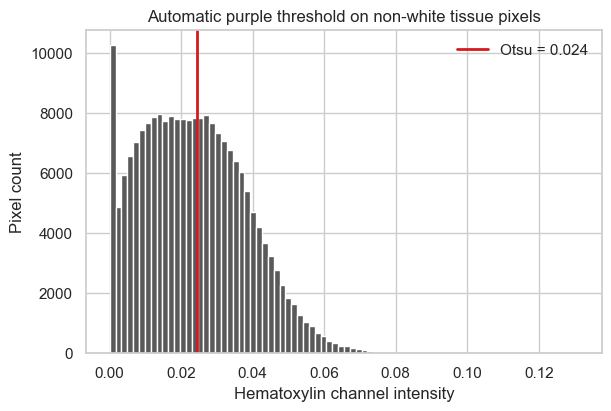

In [123]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
vals = hematoxylin[threshold_context]
ax.hist(vals[np.isfinite(vals)], bins=80, color='0.35')
ax.axvline(purple_threshold, color='#d7191c', linewidth=2, label=f'Otsu = {purple_threshold:.3f}')
ax.set_xlabel('Hematoxylin channel intensity')
ax.set_ylabel('Pixel count')
ax.set_title('Automatic purple threshold on non-white tissue pixels')
ax.legend(frameon=False)
fig.savefig(FIG_DIR / 'human_colon_hematoxylin_otsu_threshold.pdf', dpi=300, bbox_inches='tight')
plt.show()


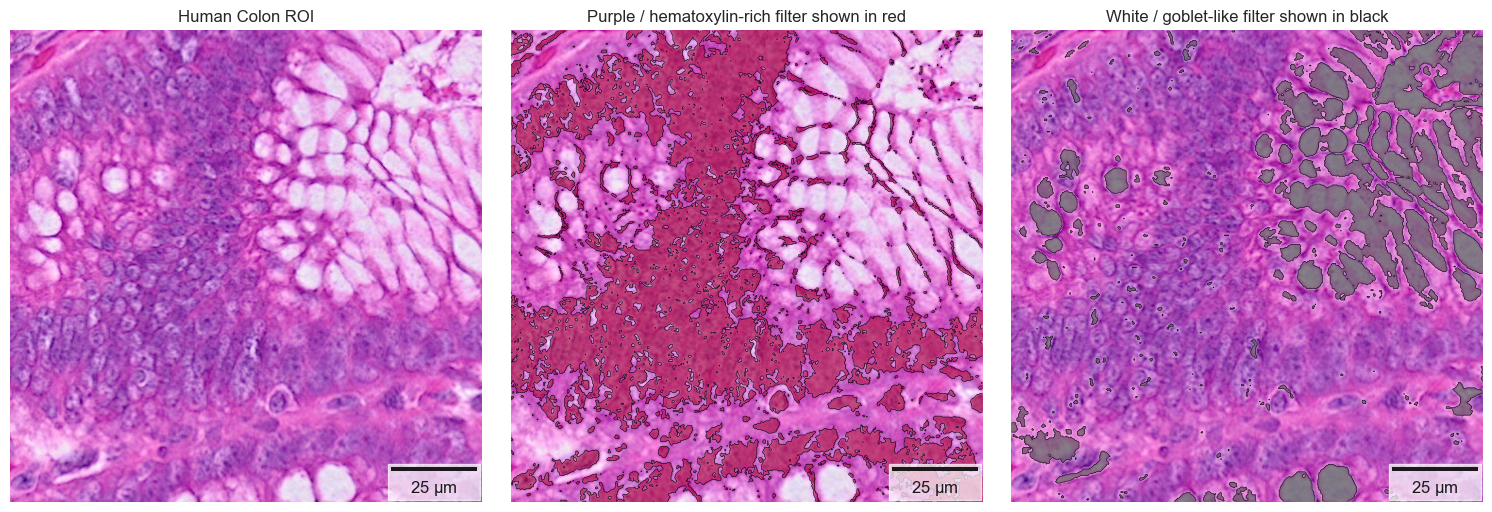

In [124]:
def add_mask_overlay(ax, base_rgb, mask, color_name, alpha=0.42):
    ax.imshow(base_rgb)
    rgba = np.zeros((*mask.shape, 4), dtype=float)
    rgba[..., :3] = to_rgb(color_name)
    rgba[..., 3] = mask.astype(float) * alpha
    ax.imshow(rgba)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

axes[0].imshow(rgb)
axes[0].set_title('Human Colon ROI')

add_mask_overlay(axes[1], rgb, purple_mask, '#d7191c')
axes[1].set_title('Purple / hematoxylin-rich filter shown in red')
axes[1].contour(purple_mask, levels=[0.5], colors='black', linewidths=0.4)

add_mask_overlay(axes[2], rgb, white_mask, '#000000', alpha=0.45)
axes[2].contour(white_mask, levels=[0.5], colors='black', linewidths=0.4)
axes[2].set_title('White / goblet-like filter shown in black')

for ax in axes:
    ax.set_axis_off()
    ax.add_artist(ScaleBar(microns_per_pixel, 'µm', length_fraction=0.25, location='lower right', box_alpha=0.7))

#fig.savefig(FIG_DIR / 'human_colon_roi_color_filters.pdf', dpi=300, bbox_inches='tight')
plt.show()


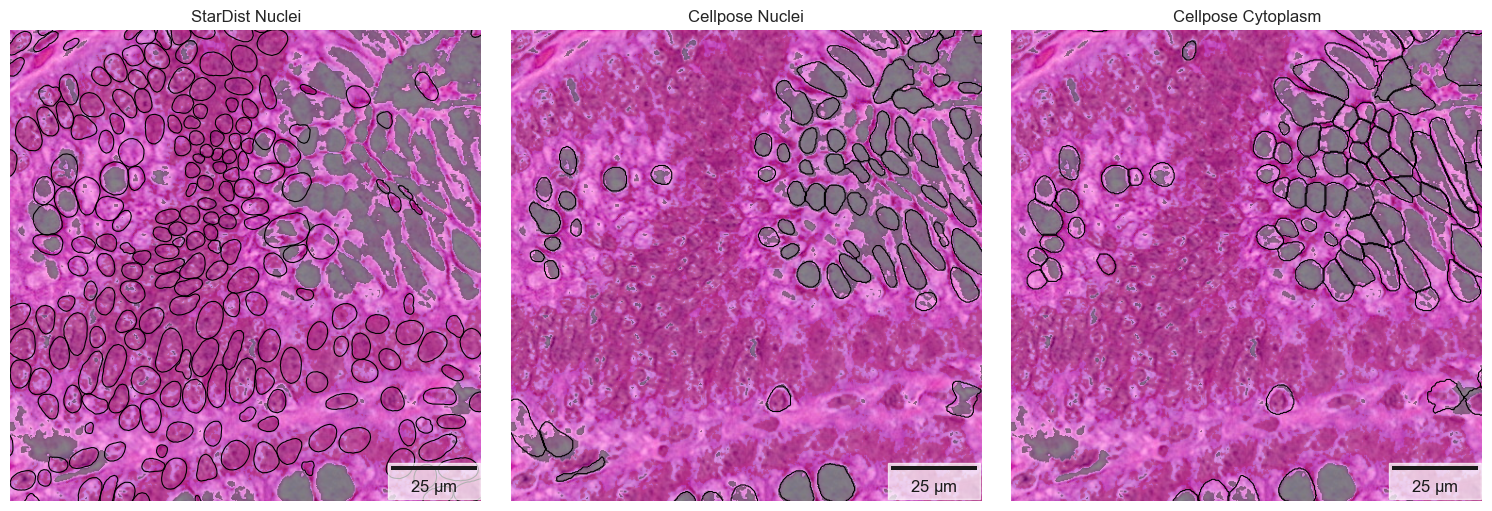

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

for ax, (method, gdf) in zip(axes, gdfs.items()):
    ax.imshow(rgb)
    add_mask_overlay(ax, rgb, purple_mask, '#d7191c', alpha=0.25)
    rgba_white = np.zeros((*white_mask.shape, 4), dtype=float)
    rgba_white[..., :3] = to_rgb('#000000')
    rgba_white[..., 3] = white_mask.astype(float) * 0.45
    ax.imshow(rgba_white)
    gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.8)
    ax.set_title(method)
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_axis_off()
    ax.add_artist(ScaleBar(microns_per_pixel, 'µm', length_fraction=0.25, location='lower right', box_alpha=0.7))

#fig.savefig(FIG_DIR / 'human_colon_three_methods_over_color_filters.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Quantitative Metrics

For each method, the notebook reports:

- **Purple coverage**: fraction of all purple pixels in the ROI that fall inside that method's segmented polygons. High values mean less nuclear-looking signal was missed.
- **Purple missed fraction**: `1 - purple coverage`. This is the direct estimate of purple signal not segmented by that method.
- **Purple purity**: fraction of the method's segmented area that is purple. High values mean the segmented regions look nuclear.
- **White coverage / missed fraction / purity**: the same calculations for bright, weakly saturated goblet-like regions. High white purity in a nuclei method is a warning sign; high white purity in a cytoplasm/goblet-prone method suggests it may be segmenting goblet/lumen-like areas instead of cells.


In [126]:
def fraction(numerator, denominator):
    return np.nan if denominator == 0 else numerator / denominator

total_purple = int(purple_mask.sum())
total_white = int(white_mask.sum())

metric_rows = []
for method, seg_mask in method_masks.items():
    seg_area = int(seg_mask.sum())
    purple_inside = int((purple_mask & seg_mask).sum())
    white_inside = int((white_mask & seg_mask).sum())

    metric_rows.append({
        'Method': method,
        'Segmented_area_px': seg_area,
        'Purple_total_px': total_purple,
        'Purple_inside_px': purple_inside,
        'Purple_outside_px': total_purple - purple_inside,
        'Purple_coverage': fraction(purple_inside, total_purple),
        'Purple_missed_fraction': fraction(total_purple - purple_inside, total_purple),
        'Purple_purity': fraction(purple_inside, seg_area),
        'White_total_px': total_white,
        'White_inside_px': white_inside,
        'White_outside_px': total_white - white_inside,
        'White_coverage': fraction(white_inside, total_white),
        'White_missed_fraction': fraction(total_white - white_inside, total_white),
        'White_purity': fraction(white_inside, seg_area),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv(FIG_DIR / 'human_colon_purple_white_method_metrics.csv', index=False)
metrics_df


,Method,Segmented_area_px,Purple_total_px,Purple_inside_px,Purple_outside_px,Purple_coverage,Purple_missed_fraction,Purple_purity,White_total_px,White_inside_px,White_outside_px,White_coverage,White_missed_fraction,White_purity
0,StarDist Nuclei,91210,94299,60335,33964,0.639827,0.360173,0.661495,44497,5647,38850,0.126907,0.873093,0.061912
1,Cellpose Nuclei,35808,94299,453,93846,0.004804,0.995196,0.012651,44497,30560,13937,0.686788,0.313212,0.853441
2,Cellpose Cytoplasm,53734,94299,3172,91127,0.033638,0.966362,0.059032,44497,33456,11041,0.751871,0.248129,0.622623


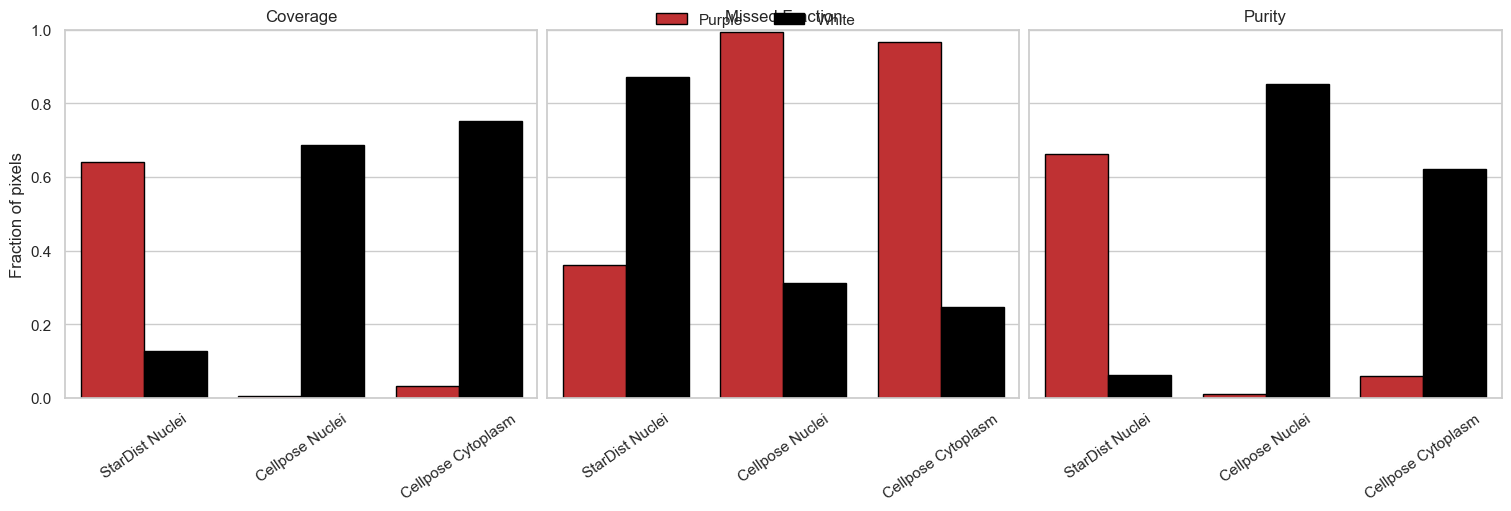

In [127]:
plot_df = metrics_df.melt(
    id_vars='Method',
    value_vars=[
        'Purple_coverage', 'Purple_missed_fraction', 'Purple_purity',
        'White_coverage', 'White_missed_fraction', 'White_purity',
    ],
    var_name='Metric',
    value_name='Fraction',
)
plot_df['Color class'] = np.where(plot_df['Metric'].str.startswith('Purple'), 'Purple', 'White')
plot_df['Metric type'] = (
    plot_df['Metric']
    .str.replace('Purple_', '', regex=False)
    .str.replace('White_', '', regex=False)
    .str.replace('_', ' ')
    .str.title()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, constrained_layout=True)
metric_order = ['Coverage', 'Missed Fraction', 'Purity']
for ax, metric_type in zip(axes, metric_order):
    sub = plot_df[plot_df['Metric type'] == metric_type]
    sns.barplot(
        data=sub,
        x='Method',
        y='Fraction',
        hue='Color class',
        palette={'Purple': '#d7191c', 'White': '#000000'},
        edgecolor='black',
        ax=ax,
    )
    ax.set_title(metric_type)
    ax.set_xlabel('')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=35)
    ax.legend_.remove()

axes[0].set_ylabel('Fraction of pixels')
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
#fig.savefig(FIG_DIR / 'human_colon_purple_white_method_metrics.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [128]:
object_rows = []
for method, gdf in gdfs.items():
    for obj_id, geom in gdf.geometry.items():
        obj_mask = rasterize_geometries([geom], (height, width))
        area = int(obj_mask.sum())
        if area == 0:
            continue
        object_rows.append({
            'Method': method,
            'Object_id': obj_id,
            'Area_px': area,
            'Purple_fraction': float((purple_mask & obj_mask).sum() / area),
            'White_fraction': float((white_mask & obj_mask).sum() / area),
            'Mean_hematoxylin': float(np.nanmean(hematoxylin[obj_mask])),
            'Mean_eosin': float(np.nanmean(eosin[obj_mask])),
            'Mean_value': float(np.nanmean(value[obj_mask])),
            'Mean_saturation': float(np.nanmean(saturation[obj_mask])),
        })

object_df = pd.DataFrame(object_rows)
object_df.to_csv(FIG_DIR / 'human_colon_purple_white_per_object_metrics.csv', index=False)
object_df.head()


,Method,Object_id,Area_px,Purple_fraction,White_fraction,Mean_hematoxylin,Mean_eosin,Mean_value,Mean_saturation
0,StarDist Nuclei,15,390,0.807692,0.005128,0.035945,0.056516,0.738210,0.565180
1,StarDist Nuclei,19,223,0.834081,0.044843,0.040762,0.049345,0.728515,0.545121
2,StarDist Nuclei,45,524,0.830153,0.000000,0.038785,0.064529,0.707252,0.615001
3,StarDist Nuclei,73,536,0.527985,0.000000,0.026028,0.057652,0.750819,0.546671
4,StarDist Nuclei,229,369,0.666667,0.000000,0.030011,0.058085,0.740975,0.559544


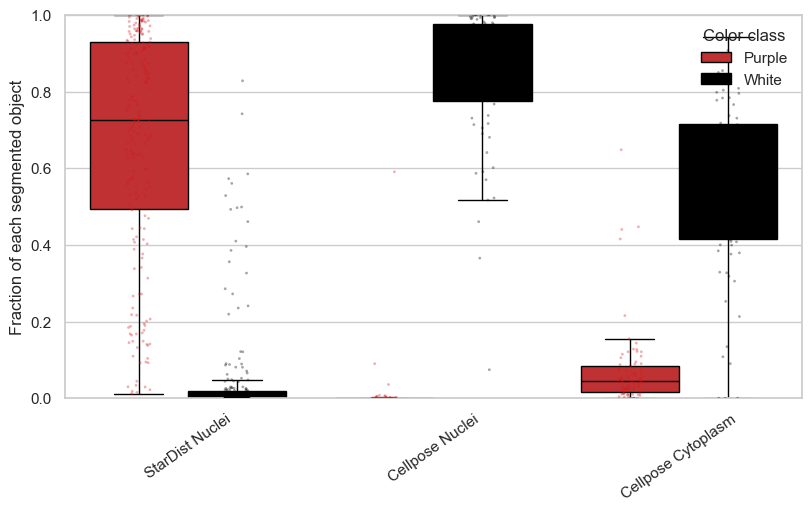

In [129]:
if object_df.empty:
    print('No rasterized segmented objects were found in this ROI; skipping per-object plot.')
else:
    object_plot_df = object_df.melt(
        id_vars=['Method', 'Object_id', 'Area_px'],
        value_vars=['Purple_fraction', 'White_fraction'],
        var_name='Color class',
        value_name='Object fraction',
    )
    object_plot_df['Color class'] = object_plot_df['Color class'].str.replace('_fraction', '', regex=False)

    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    sns.boxplot(
        data=object_plot_df,
        x='Method',
        y='Object fraction',
        hue='Color class',
        palette={'Purple': '#d7191c', 'White': '#000000'},
        fliersize=0,
        ax=ax,
    )
    sns.stripplot(
        data=object_plot_df,
        x='Method',
        y='Object fraction',
        hue='Color class',
        palette={'Purple': '#d7191c', 'White': '#000000'},
        dodge=True,
        alpha=0.35,
        size=2,
        linewidth=0,
        ax=ax,
    )
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Color class', frameon=False, loc='upper right')
    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    ax.set_ylabel('Fraction of each segmented object')
    ax.tick_params(axis='x', rotation=35)
    #fig.savefig(FIG_DIR / 'human_colon_purple_white_per_object_fractions.pdf', dpi=300, bbox_inches='tight')
    plt.show()
